In [39]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [40]:
import rioss_prep_training.rioss_callbacks as rc
import rioss_prep_training.rioss_dataset as rd
import rioss_prep_training.rioss_models.TransferModels as tm
import rioss_prep_training.rioss_models.UnetrModels as urm
import rioss_prep_training.rioss_transforms as rt

from torch import set_float32_matmul_precision
import time
from tqdm import tqdm

set_float32_matmul_precision('medium')
import os
import json
from torchvision.transforms import Compose
from monai.transforms import RandRotate90d, RandAxisFlipd, SignalFillEmptyd, ToTensord, LoadImaged, Resized
from torch.utils.data import Dataset, Sampler, DataLoader, BatchSampler
import torch
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [43]:
JSON_PATH_SPLIT = "/mnt/camobi_3/new_data/train_val.json"
files_path = Path('/mnt/camobi_process/test_dataset')
file_path = files_path / 'D205.nc'
label_order_path = '/mnt/camobi_3/new_data/label_order.json'

CLASS_WEIGHTS = {
"oil": 80,
"ship": 2,
"lookalike": 120,
"wind": 0,
"rain": 0,
"land": 5,
"biofilm": 0,
"border": 5,
"ocean": 15
}
transforms = Compose([
            ToTensord(keys=["img"], dtype=torch.float),
            ToTensord(keys=["label"], dtype=torch.uint8),
            rt.ToBinaryTransformd(keys=["label"], label_num=1),
            SignalFillEmptyd(keys=["img", "label"], replacement=0.0),
            rt.EnsureChanellFirstd(keys=["img", "label"]),
            Resized(keys=["img", "label"], spatial_size=(512, 512), mode=['nearest', 'nearest']),
            RandAxisFlipd(keys=["img", "label"], prob=2/3),
            RandRotate90d(keys=["img", "label"], prob=3/4)
])



test_ds = rd.RiossDataset(list(files_path.glob('*.nc')), 2048, CLASS_WEIGHTS, transforms=transforms, label_order_path=label_order_path, overlap=0.5, wind_speed=True, filter_min=0.015)
sampler = rd.RiossSimpleSampler(test_ds.weighted_arr(), num_samples=10, generator=None, names_extended=None)
test_dl = DataLoader(test_ds, sampler=sampler, num_workers=0)

  0%|          | 0/105 [00:00<?, ?it/s]

100%|██████████| 105/105 [00:00<00:00, 258.51it/s]


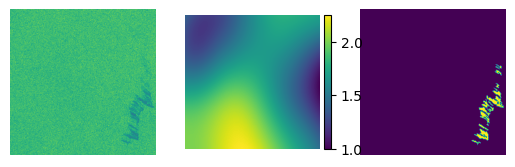

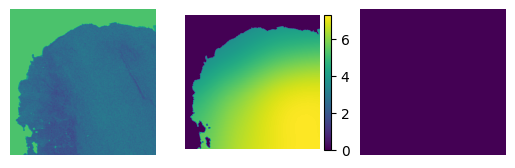

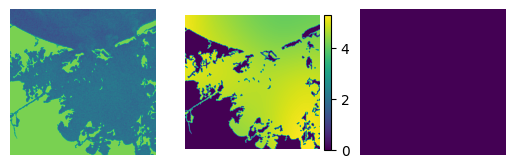

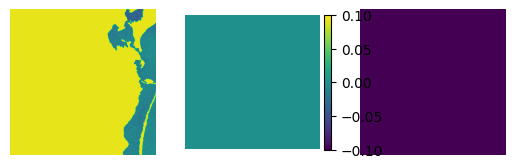

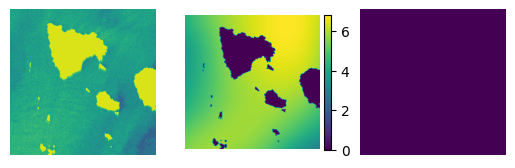

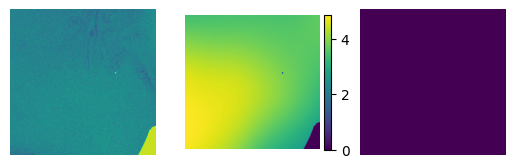

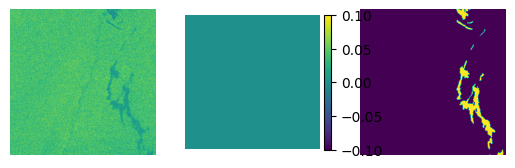

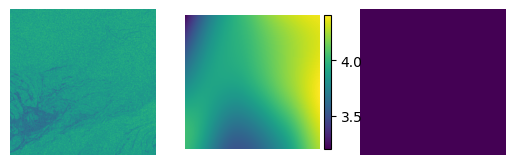

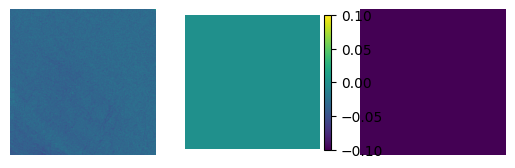

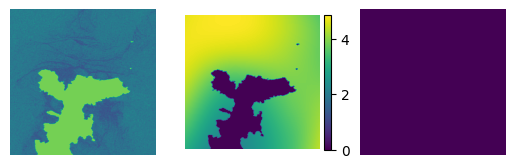

In [44]:
for item in iter(test_dl):
    fig, axs = plt.subplots(ncols=3)
    axs[0].imshow(item['img'][0][0])
    axs[0].axis('off')

    im = axs[1].imshow(item['img'][0][1])
    divider = make_axes_locatable(axs[1])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs[1].axis('off')

    axs[2].imshow(item['label'][0][0])
    axs[2].axis('off')

In [32]:
path_dir = Path('/mnt/camobi_process/test_dataset')

for path in path_dir.glob('*.nc'):
    test = xr.open_dataset(path)
    print(path)
    number = test.wind_speed.isel(x=4000, y=4000).values

/mnt/camobi_process/test_dataset/A8A3.nc
/mnt/camobi_process/test_dataset/2EBC.nc
/mnt/camobi_process/test_dataset/D205.nc
/mnt/camobi_process/test_dataset/4DB8.nc
/mnt/camobi_process/test_dataset/0868.nc
/mnt/camobi_process/test_dataset/F8D3.nc
/mnt/camobi_process/test_dataset/C094.nc
/mnt/camobi_process/test_dataset/8578.nc
/mnt/camobi_process/test_dataset/0586.nc
/mnt/camobi_process/test_dataset/8E5F.nc
/mnt/camobi_process/test_dataset/CCBB.nc
/mnt/camobi_process/test_dataset/C500.nc
/mnt/camobi_process/test_dataset/9945.nc
/mnt/camobi_process/test_dataset/898E.nc
/mnt/camobi_process/test_dataset/515A.nc
/mnt/camobi_process/test_dataset/6A96.nc
/mnt/camobi_process/test_dataset/26B9.nc
/mnt/camobi_process/test_dataset/4E69.nc
/mnt/camobi_process/test_dataset/5467.nc
/mnt/camobi_process/test_dataset/A316.nc
/mnt/camobi_process/test_dataset/6E03.nc
/mnt/camobi_process/test_dataset/B72A.nc
/mnt/camobi_process/test_dataset/7141.nc
/mnt/camobi_process/test_dataset/FAB0.nc
/mnt/camobi_proc

In [33]:
test

<xarray.Dataset>
Dimensions:           (y: 13589, x: 17098, y_div: 1698, x_div: 2137)
Coordinates:
    lon               (y, x) float64 ...
    lat               (y, x) float64 ...
  * y_div             (y_div) int64 0 1 2 3 4 5 ... 1693 1694 1695 1696 1697
  * x_div             (x_div) int64 0 1 2 3 4 5 ... 2132 2133 2134 2135 2136
Dimensions without coordinates: y, x
Data variables:
    sigma0            (y, x) float32 ...
    incident_angle    (y, x) float32 ...
    label             (y, x) int8 ...
    extracted_values  (y_div, x_div) int8 ...
    sigma0_min        float32 ...
    sigma0_max        float32 ...
    sigma0_std        float32 ...
    sigma0_mean       float32 ...
    sample_gap        int64 ...
    wind_speed        (y, x) float64 ...
Attributes:
    Conventions:  CF-1.4
    TileSize:     380:412
    start_date:   12-APR-2022 00:15:50.885844
    stop_date:    12-APR-2022 00:16:18.818799
    title:        Sentinel-1 IW Level-1 SLC Product

In [34]:
ONC_PATH = Path('/mnt/camobi_3/new_data/ocn_nc')
NC_DATASET = Path('/mnt/camobi_process/new_rioss_dataset')

for onc_path_file in ONC_PATH.glob('*.nc'):
    for nc_file_path in NC_DATASET.glob('*.nc'):
        if onc_path_file.stem == nc_file_path.stem:
            print(onc_path_file.stem)
            nc_file = xr.open_dataset(nc_file_path)
            sigma0 = nc_file.sigma0
            onc_file = xr.open_dataset(onc_path_file)
            owiEcmwfWindSpeed = onc_file.owiEcmwfWindSpeed

            
            


            
            break
    break


763B


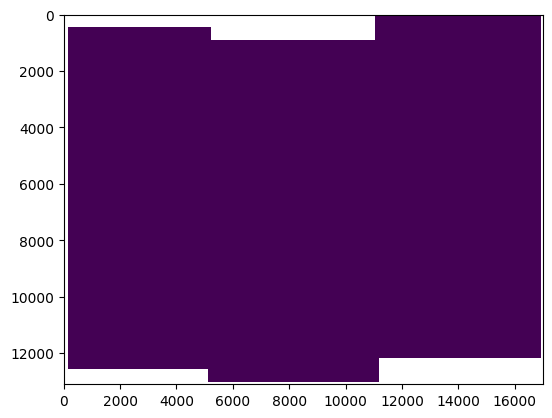

In [35]:
test = xr.open_dataset('/mnt/camobi_process/test_dataset/8578.nc')
plt.imshow(test.wind_speed)

In [36]:
owiEcmwfWindSpeed = owiEcmwfWindSpeed.rename({"owiAzSize": "y", "owiRaSize": "x"})

wind_speed_lat = onc_file.owiLat
wind_speed_lon = onc_file.owiLon


owiEcmwfWindSpeed = owiEcmwfWindSpeed.assign_coords(
    lat=(('y', 'x'), wind_speed_lat.values),
    lon=(('y', 'x'), wind_speed_lon.values)
)

target_coords = {
    'x':sigma0.x.values,
    'y':sigma0.y.values,
}

In [37]:
%%time
from scipy.interpolate import bisplrep, bisplev
from scipy.interpolate import griddata
import numpy as np
import xarray as xr
from skimage.transform import resize

wind_speed_lat = owiEcmwfWindSpeed.lat.values
wind_speed_lon = owiEcmwfWindSpeed.lon.values

factor = 4
sigma0_lat = sigma0.lat.values[::factor,::factor]
sigma0_lon = sigma0.lon.values[::factor,::factor]

interpolated_data = griddata(
    (wind_speed_lat.ravel(), wind_speed_lon.ravel()),
    owiEcmwfWindSpeed.values.ravel(),
    (sigma0_lat, sigma0_lon),
    fill_value=np.nan,
    method='linear',
    rescale=True,
)

output_grid = resize(
    interpolated_data, 
    sigma0.shape,
    order=1,
    mode='constant',
    cval=np.nan,
    anti_aliasing=False
)

mask = np.isnan(sigma0.values)
output_grid[mask] = np.nan


CPU times: user 19.3 s, sys: 13 s, total: 32.3 s
Wall time: 34.5 s


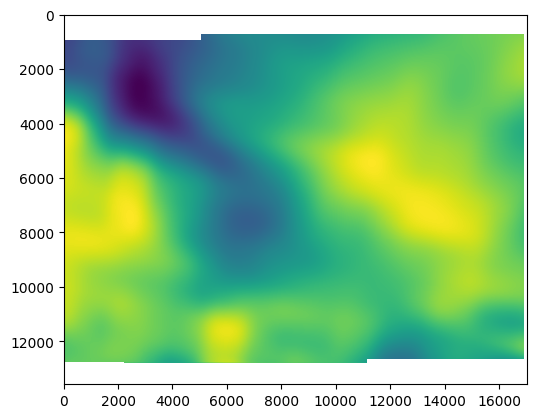

In [38]:
plt.imshow(output_grid)